# A/B Test Analysis for Online Shooter Game

### Business Context
The company developed a popular free-to-play team shooter. The game features an in-game currency that can be earned through gameplay or purchased with real money. Recently, an A/B test was conducted: a specific group of players was offered premium armor at a discount.

### Project Goals
The management wants to evaluate the impact of this promotion on key financial and behavioral metrics:
*   **ARPU** (Average Revenue Per User)
*   **ARPPU** (Average Revenue Per Paying User)
*   **In-game currency spending**

### Objective
Determine whether the promotion should be implemented globally. If the test group demonstrates a statistically significant increase in revenue compared to the control group, the campaign will be considered successful.

# Step 1. Plan

In this section, I load the raw datasets, perform an initial inspection of structure and data types, clean and merge data.

Thare are 5 tables to explore:

● Money — a table with payments.

● Cheaters — a table with detected cheaters.

● Platforms — a table with gaming platforms (PC, PS4, Xbox).

● Cash — a table with in-game currency spending.

● ABgroup — a table with the distribution of players by test groups.

In [1]:
# Importing essential libraries for analysis, statistics, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.stats.api as sms
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [2]:
# Load dataframe
group = pd.read_csv('Desktop/ABtest_project/ABgroup.csv')
group.head()

,user_id,group
0,VX6NLA-F5YMSW,control
1,2AXN3D-71ZN86,test
2,K78V3J-TQMV6F,test
3,Z2KEIG-LY3V4H,test
4,ND92RZ-SHG980,control


In [3]:
# Explore data
group.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8640000 entries, 0 to 8639999
Data columns (total 2 columns):
 #   Column   Dtype 
---  ------   ----- 
 0   user_id  object
 1   group    object
dtypes: object(2)
memory usage: 131.8+ MB


The raw datasets contain over 8.6 million entries. Вata types match.

In [4]:
# Find dublicates
print(group.duplicated().sum())
print (group.nunique())

7560000
user_id    1080000
group            2
dtype: int64


**Unique Users:** There are exactly 1,080,000 unique users across the datasets. 

**Duplicate Issue:** I detected a significant duplication issue (7.56 million duplicate rows per table). This suggests that the data was logged multiple times or follows a daily time-series structure.

In [5]:
cheaters = pd.read_csv('Desktop/ABtest_project/Cheaters.csv')
cheaters.head()

,user_id,cheaters
0,TWLWB9-L19SYJ,0
1,SD0L4U-1JG4WN,0
2,QZVG35-P8JKNU,0
3,S2VBV4-ZKBHI6,0
4,DDGKMQ-45SP8R,0


In [6]:
cheaters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8640000 entries, 0 to 8639999
Data columns (total 2 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   user_id   object
 1   cheaters  int64 
dtypes: int64(1), object(1)
memory usage: 131.8+ MB


In [7]:
print(cheaters.duplicated().sum())
print (cheaters.nunique())

7560000
user_id     1080000
cheaters          2
dtype: int64


In [8]:
cash = pd.read_csv('Desktop/ABtest_project/Cash.csv')
cash.head()

,user_id,date,cash
0,GGLSXL-U5BGGY,17.07.2021,200
1,DPWFFN-NL3VF8,16.07.2021,150
2,PASNNG-GVW4RR,11.07.2021,1100
3,4F0AW7-F40GY9,15.07.2021,1050
4,CEY6AF-YTSM4V,15.07.2021,150


In [9]:
cash.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8640000 entries, 0 to 8639999
Data columns (total 3 columns):
 #   Column   Dtype 
---  ------   ----- 
 0   user_id  object
 1   date     object
 2   cash     int64 
dtypes: int64(1), object(2)
memory usage: 197.8+ MB


In [10]:
print(cash.nunique())
print(cash.duplicated().sum())

user_id    1080000
date             8
cash           507
dtype: int64
0


In [11]:
money = pd.read_csv('Desktop/ABtest_project/Money.csv')
money.head()

,user_id,date,money
0,N4TS2T-P7YTVX,15.07.2021,1.99
1,NX9S0D-VM20W8,16.07.2021,0.99
2,QYY6FW-FKHRND,15.07.2021,0.00
3,BRWH4Y-LPGBU6,14.07.2021,0.00
4,8O317F-4ASK53,13.07.2021,0.00


In [12]:
money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8640000 entries, 0 to 8639999
Data columns (total 3 columns):
 #   Column   Dtype  
---  ------   -----  
 0   user_id  object 
 1   date     object 
 2   money    float64
dtypes: float64(1), object(2)
memory usage: 197.8+ MB


In [13]:
print(money.nunique())
print(money.duplicated().sum())

user_id    1080000
date             8
money           11
dtype: int64
0


I identified that the 8.6 million rows represent 1,080,000 unique users observed over an 8-day period. This time-series structure is consistent across the `money` and `cash` tables.

I am converting the 'date' columns to `datetime` format to enable accurate merging and future time-series analysis.

In [14]:
money['date'] = pd.to_datetime(money['date'], dayfirst = True)
money['date'].dtype

dtype('<M8[ns]')

In [15]:
cash['date'] = pd.to_datetime(cash['date'], dayfirst = True)
cash['date'].dtype

dtype('<M8[ns]')

In [16]:
platforms = pd.read_csv('Desktop/ABtest_project/Platforms.csv')
platforms.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8640000 entries, 0 to 8639999
Data columns (total 2 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   user_id   object
 1   platform  object
dtypes: object(2)
memory usage: 131.8+ MB


In [17]:
print(platforms.nunique())
print(platforms.duplicated().sum())

user_id     1080000
platform          3
dtype: int64
7560000


**Deduplication of Static Attributes:**

The `group`, `platforms`, and `cheaters` tables contain static user information. I am removing the 8-fold duplication in these tables to achieve "1 user = 1 row" granularity. This prevents data inflation during the merging process.

In [18]:
group = group.drop_duplicates().reset_index(drop=True)
cheaters = cheaters.drop_duplicates().reset_index(drop=True)
platforms = platforms.drop_duplicates().reset_index(drop=True)

### Data Merging
At this final stage of the Plan phase, I am merging all five datasets into a single dataframe (`df`). 

**Logic of the Merge:**
1.  **Fact Tables:** I performed an `outer join` on `money` and `cash` using both `user_id` and `date` as keys. This preserves every day of the test for every user, even if they had zero transactions.
2.  **Static Attributes:** I then applied a `left join` to attach `group`, `platform`, and `cheaters` information using `user_id`.

This resulting dataset maintains the daily granularity required for both behavioral and time-series analysis.

In [19]:
df = money.merge(cash, on=['user_id', 'date'], how='outer')

In [20]:
df = df.merge(group, on='user_id', how='left')
df = df.merge(platforms, on='user_id', how='left')
df = df.merge(cheaters, on='user_id', how='left')

In [21]:
df.head()

,user_id,date,money,cash,group,platform,cheaters
0,00036L-1T885I,2021-07-10,0.00,700,control,XBox,0
1,00036L-1T885I,2021-07-11,0.00,0,control,XBox,0
2,00036L-1T885I,2021-07-12,0.99,1500,control,XBox,0
3,00036L-1T885I,2021-07-13,0.00,850,control,XBox,0
4,00036L-1T885I,2021-07-14,0.00,650,control,XBox,0


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8640000 entries, 0 to 8639999
Data columns (total 7 columns):
 #   Column    Dtype         
---  ------    -----         
 0   user_id   object        
 1   date      datetime64[ns]
 2   money     float64       
 3   cash      int64         
 4   group     object        
 5   platform  object        
 6   cheaters  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 461.4+ MB


In [23]:
# Check missing values
df.isna().sum()

user_id     0
date        0
money       0
cash        0
group       0
platform    0
cheaters    0
dtype: int64

# Step 2. Analyze: Exploratory Data Analysis (EDA)

In this phase, I examine the distributions of key variables and identify anomalies. The goal is to ensure data quality before running statistical tests.

In [24]:
# Initial Statistical Summary
pd.options.display.float_format = '{:.2f}'.format
df.describe()

,date,money,cash,cheaters
count,8640000,8640000.00,8640000.00,8640000.00
mean,2021-07-13 12:00:00.000013824,0.75,763.40,0.00
min,2021-07-10 00:00:00,0.00,0.00,0.00
25%,2021-07-11 18:00:00,0.00,250.00,0.00
50%,2021-07-13 12:00:00,0.99,700.00,0.00
75%,2021-07-15 06:00:00,0.99,1150.00,0.00
max,2021-07-17 00:00:00,9.99,148200.00,1.00
std,NaN,0.79,883.61,0.02


*   **Money:** The average daily revenue per row is 0.75, with a maximum of 9.99.
*   **Cash:** There is a massive variance in in-game currency spending. While 75% of users spend less than 1,150, the maximum reaches 148,200. This is a strong indicator of outliers.

In [25]:
# Group Balance Check
df.groupby('group')['user_id'].count()

group
control    4322776
test       4317224
Name: user_id, dtype: int64

The split ratio is approximately **50/50**. This confirms that the randomization was executed correctly and the sample sizes are large enough to provide high statistical power for the test.

### Visual Analysis: Cash Spending by Cheater Status
The boxplot compares in-game currency spending (`cash`) between officially flagged cheaters (1) and other players (0).

<Axes: xlabel='cheaters', ylabel='cash'>

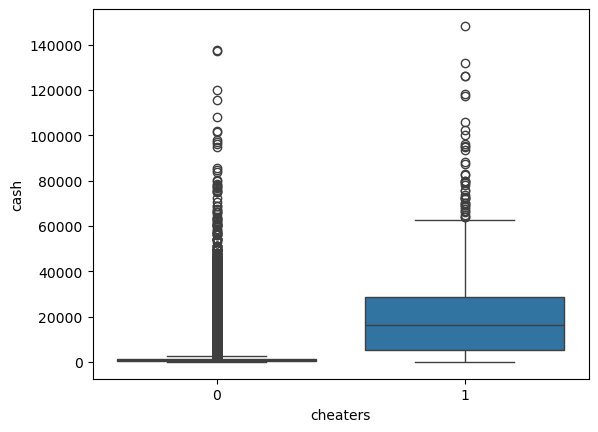

In [26]:
sns.boxplot(x = 'cheaters', y = 'cash', data = df)


**Group 1 (Known Cheaters):** Demonstrates significantly higher spending patterns, but some users have low values, possibly due to being caught early in the test.
**Group 0 (Potential Hidden Cheaters):** While the majority of players have low spending, there is a dense "cloud" of extreme outliers reaching up to 140,000 cash. 
**Insight:** The behavior of these high-spending outliers in Group 0 is identical to the behavior of Group 1. These are likely "undetected cheaters."

I must define a threshold to filter out these hidden cheaters and extreme outliers to prevent them from skewing the A/B test results.

In [27]:
# Define threshold
threshold = df[df['cheaters'] == 0]['cash'].quantile(0.999)
print(f"Spending threshold: {threshold:.2f}")

# Count of hidden_cheaters
hidden_cheaters = df[(df['cheaters'] == 0) & (df['cash'] > threshold)]
print(f"Count of hidden_cheaters: {len(hidden_cheaters)}")

Spending threshold: 5100.00
Count of hidden_cheaters: 8608


### Filtering Outliers and Cheaters
To ensure the integrity of the A/B test, I filtered the dataset to remove two types of anomalies:
 **Flagged Cheaters:** Users officially identified by the system.
 **Hidden Outliers:** Users whose in-game currency spending exceeded the calculated 99.9th percentile threshold ($5,100$). 

In [28]:
df_clean = df[(df['cheaters'] == 0) & (df['cash'] < threshold)]
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8628030 entries, 0 to 8639999
Data columns (total 7 columns):
 #   Column    Dtype         
---  ------    -----         
 0   user_id   object        
 1   date      datetime64[ns]
 2   money     float64       
 3   cash      int64         
 4   group     object        
 5   platform  object        
 6   cheaters  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 526.6+ MB


**Cleaned Dataset Size:** 8,628,030 records.

### Core Metric Calculation: ARPU
I calculated the **ARPU (Average Revenue Per User)** for both groups. ARPU is our primary success metric as it captures the overall financial performance across the entire player base, including both paying and non-paying users.

**Formula:**
$$ARPU = \frac{Total Revenue}{Total Number of Users}$$

In [29]:
summary = df_clean.groupby('group').agg(
    total_revenue = ('money', 'sum'),
    total_users = ('user_id', 'count')
)

summary['ARPU'] = summary['total_revenue'] / summary['total_users']

print(summary)


         total_revenue  total_users  ARPU
group                                    
control     3132212.04      4317669  0.73
test        3296643.40      4310361  0.76


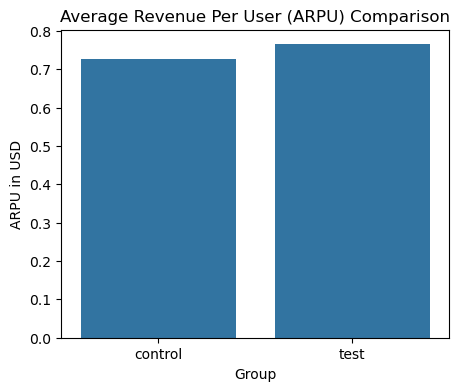

In [41]:
# Barplot for ARPU
plt.figure(figsize=(5, 4))
ax = sns.barplot(x='group', y='ARPU', data=summary)
plt.title('Average Revenue Per User (ARPU) Comparison', fontsize=12)
plt.ylabel('ARPU in USD')
plt.xlabel('Group')
plt.show()

The bar chart illustrates a clear difference in performance between the two groups:

**Control Group:** ARPU = **$0.73**

**Test Group:** ARPU = **$0.76**


**Revenue Growth:** The test group (discounted armor) shows a **4.1% increase** in ARPU compared to the control group.

**Conclusion:** The promotion appears to have a positive impact on monetization. 

#### Time-Series Analysis: Daily ARPU Trends
To ensure the observed uplift is consistent and not caused by a single-day anomaly, I analyze the daily ARPU performance throughout the 8-day test period.

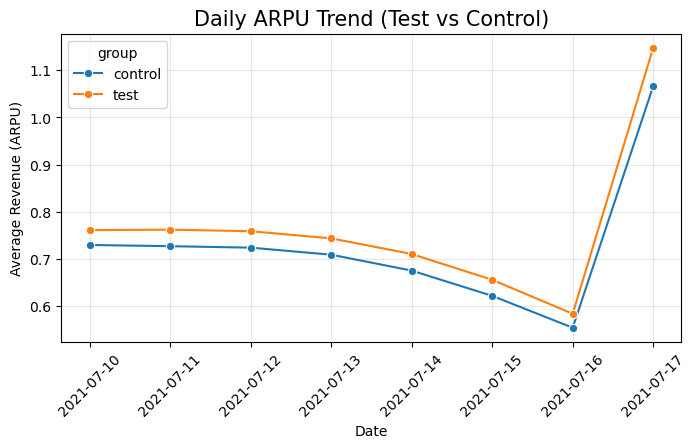

In [31]:
# 1. Grouping data by date and group
daily_metrics = df_clean.groupby(['date', 'group'])['money'].mean().reset_index()

# 2. Line graph
plt.figure(figsize=(8, 4))
sns.lineplot(data=daily_metrics, x='date', y='money', hue='group', marker='o')
plt.title('Daily ARPU Trend (Test vs Control)', fontsize=15)
plt.ylabel('Average Revenue (ARPU)')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()


*   **Persistent Uplift:** The Test group consistently outperformed the Control group every single day of the experiment. This demonstrates that the armor discount had a stable, ongoing positive impact on revenue.
*   **Synchronized Behavior:** Both groups follow identical trends (dips and peaks), which confirms that external factors (e.g., server stability, day-of-week effects) affected both groups equally, ensuring a fair comparison.
*   **The Final Day Spike (July 17th):** A significant revenue surge is observed on the final day. This is likely due to the "End-of-Sale" effect, where players rush to take advantage of the discount before the promotion expires, combined with a weekend activity peak.

**Conclusion:** The daily trend analysis reinforces the statistical findings. The promotion didn't just work on average; it worked consistently over time.

#### Platform Analysis

The boxplot shows how gaming platform influence spending behavior.

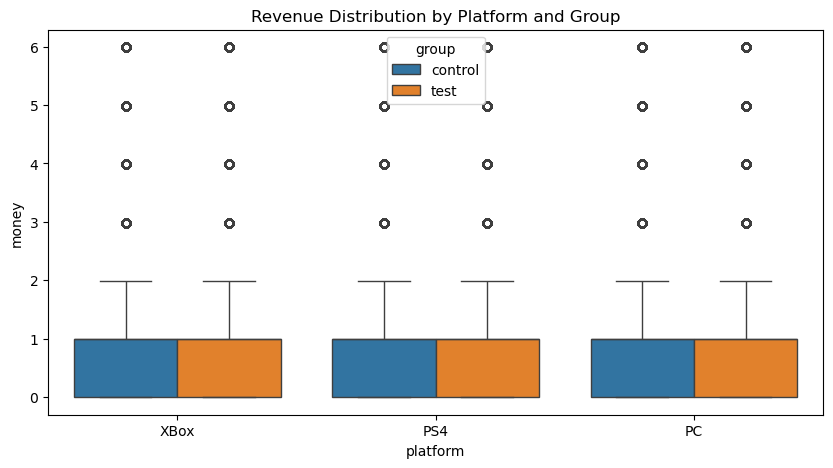

In [49]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="platform", y="money", hue="group", data=df_clean)
plt.title("Revenue Distribution by Platform and Group")
plt.show()

The boxplot shows that spending distributions are identical across Xbox, PS4, and PC. This indicates that the platform is not a significant predictor of revenue in this specific experiment.

# Step 3. Construct

In this phase, I apply statistical methods to validate the A/B test results and use machine learning for deeper player segmentation.

## Statistical Significance Testing
To confirm that the $4.1\%$ uplift in ARPU is not due to random chance, I performed two types of analysis:
1.  **95% Confidence Intervals (CI):** Calculating the range where the true population mean likely lies.
2.  **T-Test:** A statistical test used to compare the means of two independent groups with unequal variances.

**Hypotheses:**
*   **Null Hypothesis ($H_0$):** There is no significant difference in ARPU between the test and control groups.
*   **Alternative Hypothesis ($H_1$):** There is a significant difference in ARPU between the groups.

In [33]:
# Divide the data into 2 groups for comparison.
control_money = df_clean[df_clean['group'] == 'control']['money']
test_money = df_clean[df_clean['group'] == 'test']['money']

### Confidence Intervals

In [34]:
# Parameters for group Control
# Total number of observations (sample size)
n_c = len(control_money)
# Average revenue for the group
mean_c = control_money.mean()
# Standard deviation (how much data spreads around the mean)
std_c = control_money.std()
# Standard error
sem_c = stats.sem(control_money)

# Parameters for group Test
n_t = len(test_money)
mean_t = test_money.mean()
std_t = test_money.std()
sem_t = stats.sem(test_money)

# Constructing 95% confidence intervals
ci_control = stats.t.interval(confidence=0.95, df=n_c-1, loc=mean_c, scale=sem_c)
ci_test = stats.t.interval(confidence=0.95, df=n_t-1, loc=mean_t, scale=sem_t)

print(f"Control 95% CI: {ci_control}")
print(f"Test 95% CI:    {ci_test}")

Control 95% CI: (np.float64(0.7247173109277679), np.float64(0.7261637269655944))
Test 95% CI:    (np.float64(0.7640742594765588), np.float64(0.7655625389261729))


1.  **No Overlap:** The interval for the Control group (0.7247 to 0.7261) and the Test group (0.7640 to 0.7655) **do not overlap**. 
2.  **Statistically Significant Difference:** Since the intervals are completely separate, we can be 95% confident that the increase in ARPU in the Test group is **not accidental**. 
3.  **Reliability:** The very narrow range of the intervals (e.g., only 0.0014 difference between the low and high bounds for Control) indicates that our sample size is large enough and our estimate of the average revenue is extremely precise.

### Hypothesis_testing: T-test

In [35]:
t_stat, p_val = stats.ttest_ind(a = control_money, b = test_money, equal_var = False)

print("=== Т-test results ===")
print(f"Т-statistics: {t_stat:.4f}")
print(f"P-value:      {p_val:.10f}")

=== Т-test results ===
Т-statistics: -74.3769
P-value:      0.0000000000


*   **T-statistic:** The value of $-74.37$ indicates a very large difference between the means relative to the spread of the data.
*   **P-value:** The result is $0.0000000000$ (effectively $< 0.05$). 

**Conclusion:** We reject the Null Hypothesis. The armor discount has a statistically significant positive effect on ARPU.

### Player Segmentation (K-Means Clustering)

To understand the diversity of our player base, I implemented a **K-Means Clustering** algorithm. This unsupervised learning approach helps identify distinct segments based on spending patterns.

#### Methodology:
1.  **Feature Engineering:** Aggregated total `money` and `cash` spent per user.
2.  **Feature Scaling:** Applied `StandardScaler` to normalize the data, ensuring that variables with larger ranges (cash) do not disproportionately influence the model.
3.  **Optimal K Search:** Used the **Silhouette Method** on a representative sample (10,000 users) to find the most natural number of clusters.

In [36]:
# Aggregated total money and cash spent per user
features = df_clean.groupby('user_id').agg({
    'money': 'sum',
    'cash': 'sum'
}).reset_index()

X = features[['money', 'cash']]

In [37]:
# Data scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

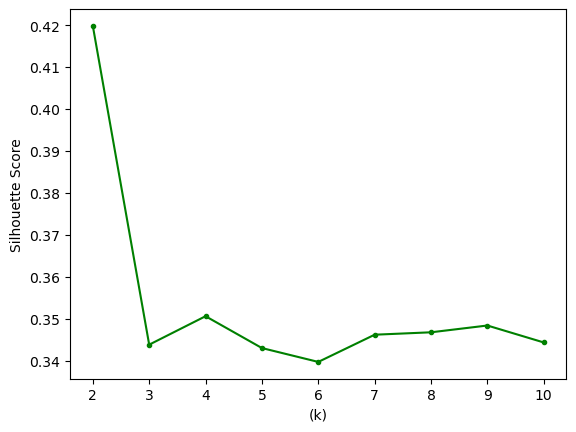

In [38]:
# Finding optimal K 
X_sample = X_scaled[np.random.choice(X_scaled.shape[0], 10000, replace=False)]

sil_scores = []
k_range = range(2, 11) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sample)
    sil_scores.append(silhouette_score(X_sample, labels))


plt.plot(k_range, sil_scores, 'g.-')
plt.xlabel('(k)')
plt.ylabel('Silhouette Score')

plt.show()

The Silhouette Score plot shows a clear peak at **k=2** (score $\approx 0.42$). 
**Interpretation:** Dividing players into two distinct clusters provides the most stable and well-separated segments.

I will proceed with k=2 to label the entire player base and analyze how the A/B test promotion affected each segment individually.

In [39]:
optimal_k = 2 

# Model Initialization
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
# Labeling
features['cluster'] = kmeans_final.fit_predict(X_scaled)

# Cluster Profiling
cluster_analysis = features.groupby('cluster').agg({
    'money': 'mean',
    'cash': 'mean',
    'user_id': 'count'
}).rename(columns={'user_id': 'player_count'})

print(cluster_analysis)

         money    cash  player_count
cluster                             
0         4.69 5051.95        575638
1         7.40 7034.07        503969


**Segment Profiles:**
*   **Cluster 0 (Casual Spenders):** Represents players with lower average spending ($4.69$ money) and moderate in-game currency usage. This is the larger group.
*   **Cluster 1 (High-Value Players):** Represents the "core" audience with significantly higher spending ($7.40$ money) and more active in-game currency circulation.

#### Segmented Uplift Analysis
To understand the true impact of the armor discount, I analyzed the **Uplift** across both segments. 
Uplift measures the percentage increase in ARPU within the Test group compared to the Control group for each specific cluster.

In [40]:
# Mapping cluster labels to the data
df_analysis = df_clean.merge(features[['user_id', 'cluster']], on='user_id', how='left')

# Calculate ARPU for each group within each cluster
final_insight = df_analysis.groupby(['cluster', 'group'])['money'].mean().unstack()

# Calculate the % increase (uplift)
final_insight['uplift_%'] = (final_insight['test'] - final_insight['control']) / final_insight['control'] * 100

print(final_insight)

group    control  test  uplift_%
cluster                         
0           0.59  0.59      0.61
1           0.92  0.93      0.38


#### Key Insights from Segmented Analysis:
**Homogeneous Impact:** Both clusters showed a positive but relatively small uplift (under 1%). This indicates that the armor discount did not cause a drastic shift in behavior for any specific group.
**Sensitivity:** **Cluster 0 (Casual Spenders)** showed a slightly higher uplift (**+0.61%**) compared to **Cluster 1 (+0.38%)**. 
    *   **Interpretation:** Lower-spending players were slightly more sensitive to the price discount. This suggests that discounts are a better tool for converting "budget-conscious" players than for increasing the spending of "whales" who likely purchase items regardless of price.
**Revenue Contribution:** Even though Cluster 1 had a lower percentage uplift, their high baseline ARPU ($0.92$) means they remain the primary revenue drivers.

**Final Decision Logic:**
The overall ARPU increase is statistically significant (as proven in Step 3.1), and it affects all player segments positively. The strategy is safe to implement, but targeted offers for Cluster 0 might yield even better results in the future.

# Step 4. Execute: Final Conclusions

### Executive Summary
The A/B test for the premium armor discount was conducted over an 8-day period with a total of 1,080,000 unique users. After data cleaning, outlier removal, and statistical validation, the promotion is considered **successful**.

### Key Findings
*   **Revenue Uplift:** The promotion led to a **4.1% increase in ARPU** (0.76 in the Test group vs 0.73 in the Control group).
*   **Statistical Significance:** The difference was confirmed by a T-test with a **p-value < 0.05** and non-overlapping 95% Confidence Intervals.
*   **Consistency:** Daily trend analysis showed that the Test group consistently outperformed the Control group throughout the entire period.
*   **Segment Impact:** Clustering revealed that "Casual Spenders" (Cluster 0) were slightly more responsive to the discount (+0.61% uplift) than "High-Value Players" (+0.38%).

### Business Recommendations
1.  **Full Rollout:** I recommend implementing the premium armor discount globally for all players, as it provides a stable and significant increase in revenue without negatively affecting any player segment.
2.  **Targeted Promotions:** Future discount campaigns should be primarily targeted at "Casual Spenders" (Cluster 0), as they show higher price elasticity.
3.  **Fraud Prevention:** The discovery of "hidden cheaters" (8.6k users) during this analysis suggests that the anti-cheat system should be updated to flag users spending over 5,100 in-game currency as high-risk.

### Project Success Evaluation
The project followed the **PACE** framework, moving from a structured data preparation plan to deep statistical analysis and machine learning segmentation. We successfully isolated the true impact of the promotion by removing fraudulent data that could have skewed the business decision.